<a href="https://colab.research.google.com/github/shailaja-ds/House-Price-Prediction/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

data = {
    "area": [800, 1000, 1200, 1500, 1800, 2000, 2200, 2500, 2800, 3000],
    "bedrooms": [2, 2, 3, 3, 3, 4, 4, 4, 5, 5],
    "bathrooms": [1, 2, 2, 2, 3, 3, 3, 4, 4, 4],
    "age": [20, 15, 10, 8, 12, 5, 7, 4, 3, 2],
    "price": [2500000, 3200000, 4000000, 5000000, 6200000,
              7000000, 7600000, 9000000, 10500000, 12000000]
}

df = pd.DataFrame(data)

print("House price dataset created successfully!")
df

House price dataset created successfully!


,area,bedrooms,bathrooms,age,price
0,800,2,1,20,2500000
1,1000,2,2,15,3200000
2,1200,3,2,10,4000000
3,1500,3,2,8,5000000
4,1800,3,3,12,6200000
5,2000,4,3,5,7000000
6,2200,4,3,7,7600000
7,2500,4,4,4,9000000
8,2800,5,4,3,10500000
9,3000,5,4,2,12000000


In [ ]:
print("Dataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nColumn Names:")
print(df.columns)

Dataset Shape:
(10, 5)

Missing Values:
area         0
bedrooms     0
bathrooms    0
age          0
price        0
dtype: int64

Duplicate Rows:
0

Column Names:
Index(['area', 'bedrooms', 'bathrooms', 'age', 'price'], dtype='object')


In [ ]:
print("Basic Statistics:")
df.describe()

Basic Statistics:


,area,bedrooms,bathrooms,age,price
count,10.000000,10.000000,10.000000,10.000000,1.000000e+01
mean,1880.000000,3.500000,2.800000,8.600000,6.700000e+06
std,756.894239,1.080123,1.032796,5.738757,3.145367e+06
min,800.000000,2.000000,1.000000,2.000000,2.500000e+06
25%,1275.000000,3.000000,2.000000,4.250000,4.250000e+06
50%,1900.000000,3.500000,3.000000,7.500000,6.600000e+06
75%,2425.000000,4.000000,3.750000,11.500000,8.650000e+06
max,3000.000000,5.000000,4.000000,20.000000,1.200000e+07


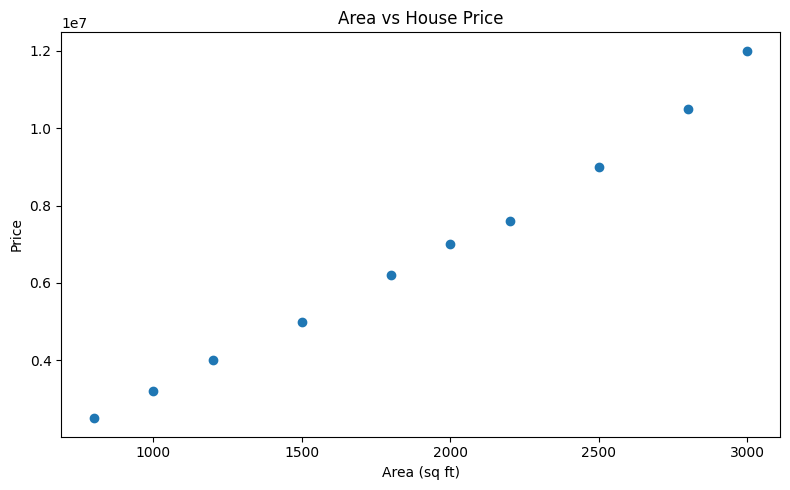

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(df["area"], df["price"])

plt.title("Area vs House Price")
plt.xlabel("Area (sq ft)")
plt.ylabel("Price")
plt.tight_layout()

plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X = df[["area", "bedrooms", "bathrooms", "age"]]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8, 4)
Testing data: (2, 4)


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [ ]:
y_pred = model.predict(X_test)

print("Actual Prices:")
print(y_test.values)

print("\nPredicted Prices:")
print(y_pred)

Actual Prices:
[10500000  3200000]

Predicted Prices:
[10750380.06756757  2676984.7972973 ]


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 386697.63513513515
Mean Squared Error (MSE): 168117540246.6443
R² Score: 0.9873809314883359


In [ ]:
new_house = pd.DataFrame({
    "area": [1600],
    "bedrooms": [3],
    "bathrooms": [2],
    "age": [6]
})

predicted_price = model.predict(new_house)

print("Predicted House Price:", predicted_price[0])

Predicted House Price: 5321157.094594594


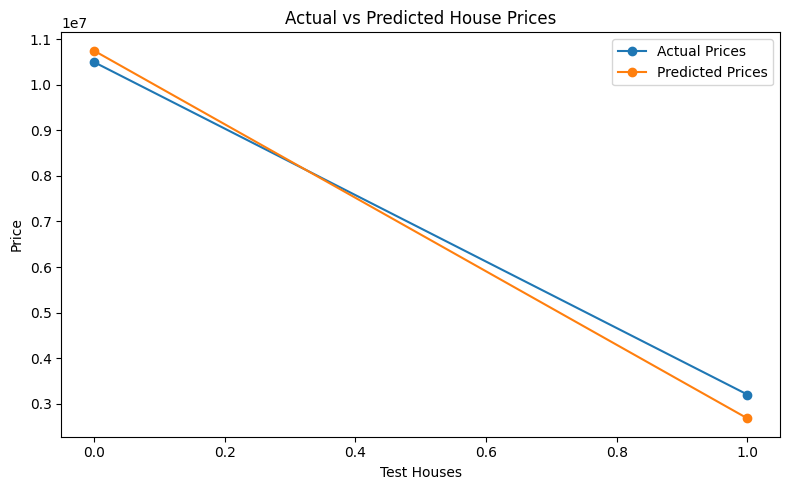

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(y_test.values, marker="o", label="Actual Prices")
plt.plot(y_pred, marker="o", label="Predicted Prices")

plt.title("Actual vs Predicted House Prices")
plt.xlabel("Test Houses")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()

plt.show()

In [ ]:
df.to_csv("dataset.csv", index=False)

print("dataset.csv created successfully!")

dataset.csv created successfully!
